# Lecture 10C.3 — Wav2Vec2 Embeddings (Windowed + Layer-wise)

This notebook implements a **windowed Wav2Vec2 embedding pipeline** for EE519.

## What you get
- Final-layer pooled embeddings for each sliding window
- Layer-wise pooled embeddings (multiple transformer layers)
- Metadata table aligning each embedding to its clip/segment/time/label
- Leakage-safe clip-level train/test split
- PCA plots per layer saved to `figures/`

## Outputs
- `features/wav2vec2_window_embeddings.npy`
- `features/wav2vec2_window_embeddings_meta.csv`
- `features/wav2vec2_layerwise_embeddings.npz`
- `results/L10C_segment_split.csv`
- `figures/L10C_wav2vec2_pca_layer_XX.png`

## Key idea: short windows + longer model context
We define short windows (e.g., 250 ms every 50 ms) but feed Wav2Vec2 a larger centered
context chunk (e.g., 1.0 s) for stable representations.


## 1) Imports + Project paths

Folder structure:
`EE519_L10C_Project/{recordings,features,results,figures}` and a `manifest.json`.


In [1]:
import os, json, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd() / "EE519_L10C_Project"
REC_DIR = PROJECT_ROOT / "recordings"
FIG_DIR = PROJECT_ROOT / "figures"
RES_DIR = PROJECT_ROOT / "results"
FEAT_DIR = PROJECT_ROOT / "features"
MANIFEST_PATH = PROJECT_ROOT / "manifest.json"

for d in [REC_DIR, FIG_DIR, RES_DIR, FEAT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def load_manifest(path=MANIFEST_PATH):
    if path.exists():
        return json.loads(path.read_text())
    return {"course":"EE519","module":"Lecture10C","created_utc":None,"clips":[],"splits":{}}

def save_fig(fig, name, dpi=150):
    out = FIG_DIR / name
    fig.savefig(out, dpi=dpi, bbox_inches="tight")
    print("Saved:", out)
    return out

import wave
def read_wav(path: Path):
    with wave.open(str(path), "rb") as wf:
        fs = wf.getframerate()
        n = wf.getnframes()
        x = np.frombuffer(wf.readframes(n), dtype=np.int16).astype(np.float32) / 32768.0
    return fs, x

def peak_normalize(x, target=0.98):
    m = np.max(np.abs(x)) + 1e-12
    return (x / m) * target

def get_segments(clip):
    return clip.get("selections", {}).get("analysis_segments", {})

manifest = load_manifest()
print("Project root:", PROJECT_ROOT)
print("Clips:", len(manifest.get("clips", [])))
for i, c in enumerate(manifest.get("clips", [])):
    print(f"[{i}] {c.get('label',''):14s}  {c.get('filename','')}")


Project root: /Users/kadiris1/Desktop/Couses-USC/Experiential learning/L10/EE519_Lecture10C_Notebooks_Release_v1/EE519_L10C_Project
Clips: 4
[0] vowel_a         student10B_vowel_a.wav
[1] vowel_i         student10B_vowel_i.wav
[2] fricative_s     student10B_fricative_s.wav
[3] sentence        student10B_sentence.wav


## 2) Config

Wav2Vec2 expects 16 kHz audio.

Default settings:
- Analysis windows: `SEG_SEC` and `HOP_SEC`
- Model context: `W2V_CONTEXT_SEC`
- Clip-level split: `TEST_RATIO`


In [2]:
RNG_SEED = 7

SEG_SEC = 0.25
HOP_SEC = 0.05
W2V_CONTEXT_SEC = 1.00
TEST_RATIO = 0.2

W2V_MODEL_NAME = "facebook/wav2vec2-base-960h"
LAYER_IDS = [0, 2, 4, 6, 8, 10, 12]

print("SEG_SEC:", SEG_SEC, "HOP_SEC:", HOP_SEC, "CONTEXT:", W2V_CONTEXT_SEC)
print("Model:", W2V_MODEL_NAME)
print("Layers:", LAYER_IDS)


SEG_SEC: 0.25 HOP_SEC: 0.05 CONTEXT: 1.0
Model: facebook/wav2vec2-base-960h
Layers: [0, 2, 4, 6, 8, 10, 12]


## 3) Load Wav2Vec2 + helpers

We use `Wav2Vec2FeatureExtractor` (no tokenizer) for robustness.


In [4]:
import scipy.signal as sig

import torch
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor

device = "cuda" if torch.cuda.is_available() else "cpu"

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(W2V_MODEL_NAME)
model = Wav2Vec2Model.from_pretrained(W2V_MODEL_NAME).to(device)
model.eval()

# deterministic embeddings
if hasattr(model.config, "apply_spec_augment"):
    model.config.apply_spec_augment = False
for attr in ["mask_time_prob", "mask_feature_prob"]:
    if hasattr(model.config, attr):
        setattr(model.config, attr, 0.0)

def resample_to_16k(x, fs):
    target = 16000
    if fs == target:
        return x.astype(np.float32), fs
    g = math.gcd(fs, target)
    up = target // g
    down = fs // g
    y = sig.resample_poly(x, up, down).astype(np.float32)
    return y, target

def sliding_frame_centers(n, fs, seg_sec=SEG_SEC, hop_sec=HOP_SEC):
    seg = int(round(seg_sec * fs))
    hop = int(round(hop_sec * fs))
    starts = list(range(0, max(1, n - seg + 1), hop))
    centers = [s + seg//2 for s in starts]
    return starts, centers, seg, hop

def extract_centered_context(x, center, fs, context_sec=W2V_CONTEXT_SEC):
    L = max(1, int(round(context_sec * fs)))
    half = L // 2
    s = center - half
    e = s + L
    y = np.zeros(L, dtype=np.float32)
    xs = max(0, s); xe = min(len(x), e)
    ys = xs - s
    ye = ys + (xe - xs)
    if xe > xs:
        y[ys:ye] = x[xs:xe].astype(np.float32)
    return y

def make_window_id(seg_name, k, t0_sec):
    return f"{seg_name}__w{k:04d}__t{t0_sec:0.3f}s"

def stratified_clip_split(clip_labels, test_ratio=TEST_RATIO, seed=RNG_SEED):
    "Split at clip level (not window level) to avoid leakage."
    rng = np.random.default_rng(seed)
    labels = np.array(clip_labels)
    idxs = np.arange(len(labels))
    test_mask = np.zeros(len(labels), dtype=bool)
    for lab in np.unique(labels):
        group = idxs[labels == lab]
        rng.shuffle(group)
        n_test = max(1, int(round(test_ratio * len(group)))) if len(group) > 1 else 1
        test_mask[group[:n_test]] = True
    return np.where(test_mask, "test", "train")

def pool_ts(H):
    return H.mean(dim=0)

print("Loaded Wav2Vec2 on", device)


Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded Wav2Vec2 on cpu


## 4) Extract embeddings (final + layer-wise)

Outputs are saved into `features/` and `results/`.


In [5]:
clip_labels = [c.get("label", "unknown") for c in manifest.get("clips", [])]
clip_split = stratified_clip_split(clip_labels)

items = []
for ci, clip in enumerate(manifest.get("clips", [])):
    segs = get_segments(clip)
    if not segs:
        wav_path = REC_DIR / clip["filename"]
        fs0, x0 = read_wav(wav_path)
        segs = {"full": {"s0": 0, "s1": len(x0)}}
    for seg_name, sel in segs.items():
        items.append((ci, seg_name, sel))

emb_rows = []
emb_mat = []
layer_to_emb = {lid: [] for lid in LAYER_IDS}

for ci, seg_name, sel in items:
    clip = manifest["clips"][ci]
    wav_path = REC_DIR / clip["filename"]
    if not wav_path.exists():
        continue

    fs, x = read_wav(wav_path)
    x = peak_normalize(x)

    s0 = int(sel["s0"]); s1 = int(sel["s1"])
    xseg = x[s0:s1]
    starts, centers, segS, hopS = sliding_frame_centers(len(xseg), fs)

    for k, (st, ct) in enumerate(zip(starts, centers)):
        t0_sec = st / fs
        win_id = make_window_id(seg_name, k, t0_sec)

        xctx = extract_centered_context(xseg, ct, fs)
        x16, fs16 = resample_to_16k(xctx, fs)

        inputs = feature_extractor(x16, sampling_rate=fs16, return_tensors="pt")
        input_values = inputs["input_values"].to(device)

        with torch.no_grad():
            out = model(input_values, output_hidden_states=True)
            h_last = out.last_hidden_state[0]
            hs = out.hidden_states

            emb = pool_ts(h_last).cpu().numpy()
            for lid in LAYER_IDS:
                layer_to_emb[lid].append(pool_ts(hs[lid][0]).cpu().numpy())

        emb_mat.append(emb)
        emb_rows.append({
            "clip_idx": ci,
            "segment": win_id,
            "base_segment": seg_name,
            "window_index": k,
            "t0_sec": float(t0_sec),
            "seg_sec": float(SEG_SEC),
            "hop_sec": float(HOP_SEC),
            "context_sec": float(W2V_CONTEXT_SEC),
            "label": clip.get("label",""),
            "filename": clip.get("filename",""),
            "group": clip.get("label",""),
            "split": clip_split[ci],
            "dim": int(emb.shape[0]),
        })

emb_mat = np.array(emb_mat)
emb_df = pd.DataFrame(emb_rows)

np.save(FEAT_DIR / "wav2vec2_window_embeddings.npy", emb_mat)
emb_df.to_csv(FEAT_DIR / "wav2vec2_window_embeddings_meta.csv", index=False)

npz_dict = {f"layer_{lid}": np.vstack(layer_to_emb[lid]) for lid in LAYER_IDS if len(layer_to_emb[lid])}
np.savez_compressed(FEAT_DIR / "wav2vec2_layerwise_embeddings.npz", **npz_dict)

split_out = RES_DIR / "L10C_segment_split.csv"
emb_df[["clip_idx","segment","group","split"]].to_csv(split_out, index=False)

print("Saved wav2vec2 outputs.")
print("Embeddings:", emb_mat.shape)
print("Meta:", emb_df.shape)
print("Layers:", list(npz_dict.keys()))


Saved wav2vec2 outputs.
Embeddings: (40, 768)
Meta: (40, 13)
Layers: ['layer_0', 'layer_2', 'layer_4', 'layer_6', 'layer_8', 'layer_10', 'layer_12']


## 5) PCA per layer

Produces one PCA plot per layer and saves to `figures/`.


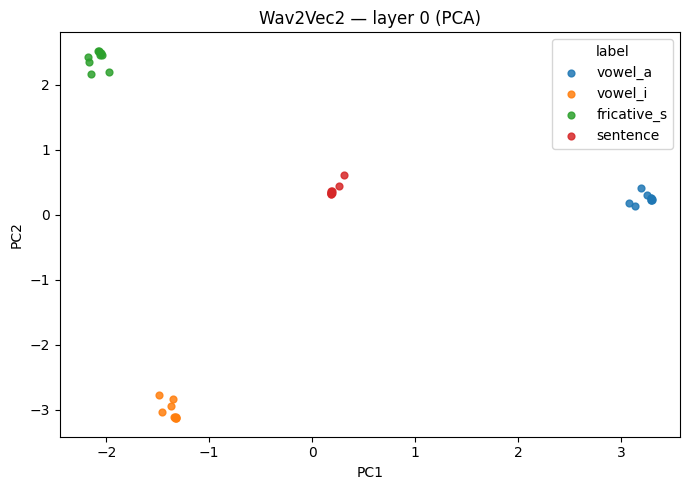

Saved: /Users/kadiris1/Desktop/Couses-USC/Experiential learning/L10/EE519_Lecture10C_Notebooks_Release_v1/EE519_L10C_Project/figures/L10C_wav2vec2_pca_layer_00.png


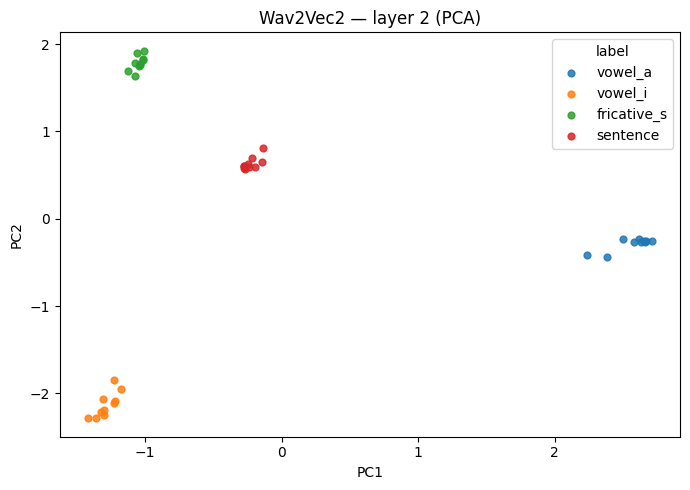

Saved: /Users/kadiris1/Desktop/Couses-USC/Experiential learning/L10/EE519_Lecture10C_Notebooks_Release_v1/EE519_L10C_Project/figures/L10C_wav2vec2_pca_layer_02.png


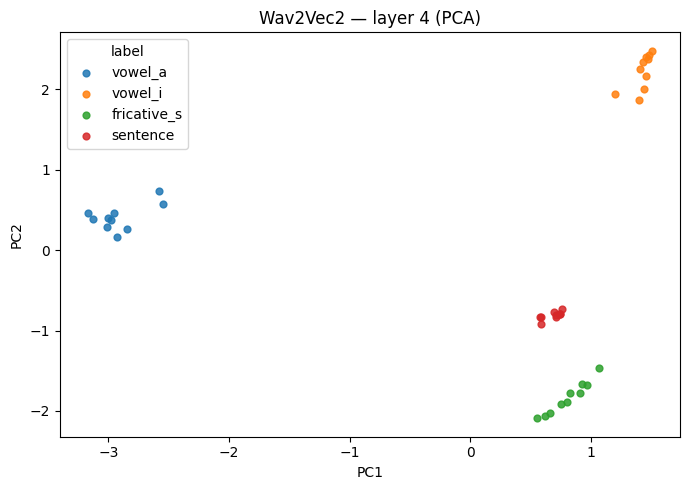

Saved: /Users/kadiris1/Desktop/Couses-USC/Experiential learning/L10/EE519_Lecture10C_Notebooks_Release_v1/EE519_L10C_Project/figures/L10C_wav2vec2_pca_layer_04.png


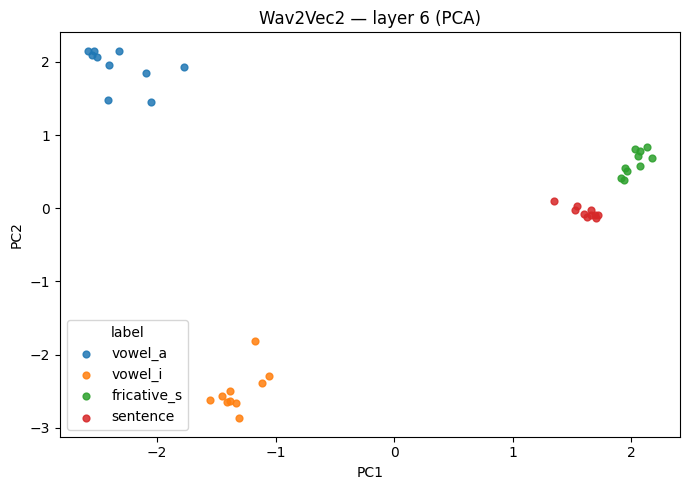

Saved: /Users/kadiris1/Desktop/Couses-USC/Experiential learning/L10/EE519_Lecture10C_Notebooks_Release_v1/EE519_L10C_Project/figures/L10C_wav2vec2_pca_layer_06.png


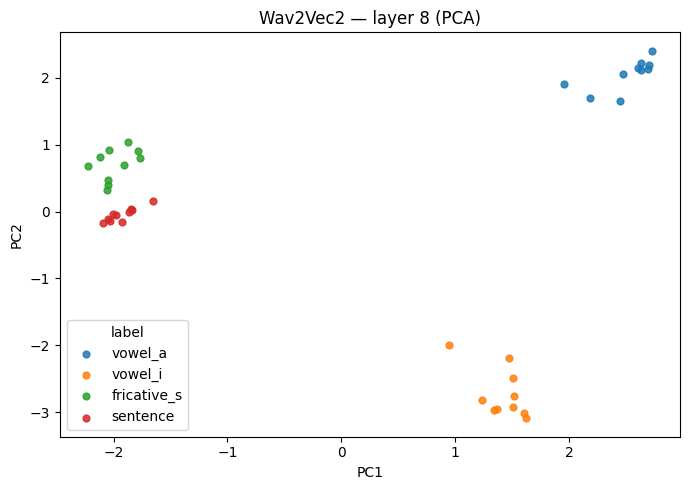

Saved: /Users/kadiris1/Desktop/Couses-USC/Experiential learning/L10/EE519_Lecture10C_Notebooks_Release_v1/EE519_L10C_Project/figures/L10C_wav2vec2_pca_layer_08.png


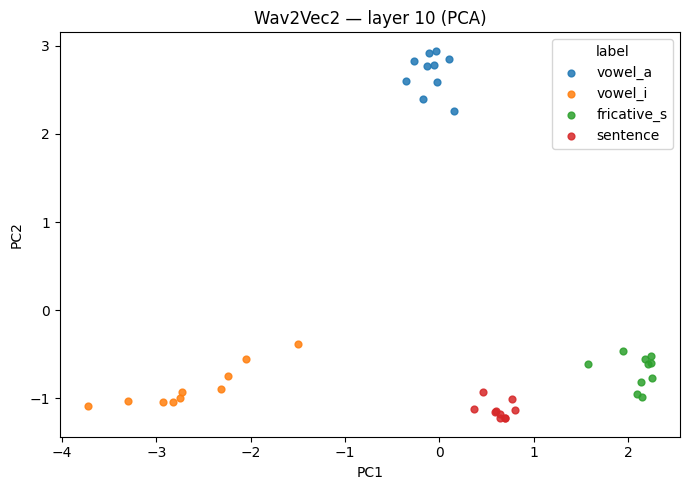

Saved: /Users/kadiris1/Desktop/Couses-USC/Experiential learning/L10/EE519_Lecture10C_Notebooks_Release_v1/EE519_L10C_Project/figures/L10C_wav2vec2_pca_layer_10.png


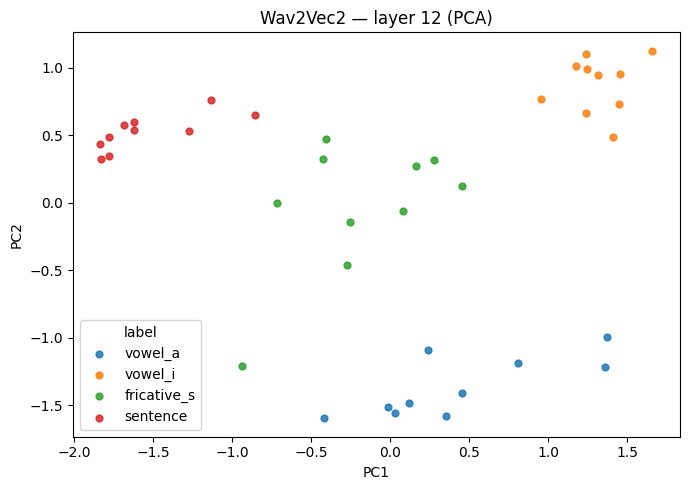

Saved: /Users/kadiris1/Desktop/Couses-USC/Experiential learning/L10/EE519_Lecture10C_Notebooks_Release_v1/EE519_L10C_Project/figures/L10C_wav2vec2_pca_layer_12.png


In [6]:
from sklearn.decomposition import PCA

split_df = pd.read_csv(RES_DIR / "L10C_segment_split.csv")
meta = pd.read_csv(FEAT_DIR / "wav2vec2_window_embeddings_meta.csv")
merged = meta.merge(split_df, on=["clip_idx","segment"], how="left")

npz = np.load(FEAT_DIR / "wav2vec2_layerwise_embeddings.npz")
keys = sorted([k for k in npz.files if k.startswith("layer_")],
              key=lambda s: int(s.split("_")[1]))

label_col = "group" if "group" in merged.columns else ("label" if "label" in merged.columns else None)

for k in keys:
    X = npz[k]
    Z = PCA(n_components=2, random_state=0).fit_transform(X)

    fig = plt.figure(figsize=(7,5))
    if label_col is None:
        plt.scatter(Z[:,0], Z[:,1], s=24, alpha=0.85)
    else:
        for g in pd.Series(merged[label_col]).dropna().unique():
            m = (merged[label_col] == g).values
            plt.scatter(Z[m,0], Z[m,1], s=24, label=str(g), alpha=0.85)
        plt.legend(title=label_col)

    lid = int(k.split("_")[1])
    plt.title(f"Wav2Vec2 — layer {lid} (PCA)")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()
    save_fig(fig, f"L10C_wav2vec2_pca_layer_{lid:02d}.png")


## Reflection questions

1) Why might embeddings outperform MFCCs on some tasks?  
2) Why might MFCCs still be preferred in low-resource or interpretable settings?  
3) What does it mean that embeddings are “learned features”?